In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier


In [78]:
# 1 Load datset
raw_data = pd.read_csv("raw_data.csv")

In [79]:
raw = raw_data.drop(["EmployeeCount","StandardHours", "Over18", "EmployeeNumber"],axis=1).copy()

In [80]:
raw['Attrition'] = raw['Attrition'].map({'No': 0, 'Yes': 1})  # 1 : Left, 0 : still there
raw['OverTime'] = raw['OverTime'].map({'No': 0, 'Yes': 1}) 

In [81]:
raw["TenureRatio"] = raw["YearsAtCompany"] / raw["TotalWorkingYears"]

In [82]:
raw['TenureRatio'] = raw['TenureRatio'].fillna(0)


In [83]:
raw["PromotionGap"] = raw["YearsAtCompany"] - raw["YearsSinceLastPromotion"]  

In [84]:
raw["IncomeLevelRatio"] = raw["MonthlyIncome"] / raw["JobLevel"]

In [85]:
X = raw.drop("Attrition", axis=1)
y = raw["Attrition"]


In [86]:
#Split the data

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(X, y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]


In [87]:
data_numeric = X_train.drop(["BusinessTravel","Department","EducationField","Gender","JobRole","MaritalStatus"],axis=1)
data_category = X_train[["BusinessTravel","Department","EducationField","Gender","JobRole","MaritalStatus"]]

# Pipelines
# Numerical pipeline

num_pipeline = Pipeline([
("imputer", SimpleImputer(strategy="median")),
("scaler", StandardScaler()),
])


In [88]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [89]:
num_cols = data_numeric.columns.tolist()
cat_cols = data_category.columns.tolist()

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [90]:
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

In [91]:
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_prepared, y_train)

y_pred_lr = lr.predict(X_test_prepared)

In [92]:
accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy)

Accuracy: 0.7482993197278912


In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.34      0.60      0.43        47

    accuracy                           0.75       294
   macro avg       0.62      0.69      0.63       294
weighted avg       0.82      0.75      0.77       294



In [94]:

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_lr))


[[192  55]
 [ 19  28]]


In [95]:
forest_reg = RandomForestClassifier(random_state=42,class_weight="balanced")
forest_reg.fit(X_train_prepared, y_train)

rf_pred = forest_reg.predict(X_test_prepared)

In [96]:
accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


In [97]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.90       247
           1       0.47      0.30      0.36        47

    accuracy                           0.83       294
   macro avg       0.67      0.62      0.63       294
weighted avg       0.81      0.83      0.82       294



In [98]:
print(confusion_matrix(y_test, rf_pred))

[[231  16]
 [ 33  14]]


In [99]:
dec_tree=DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dec_tree.fit(X_train_prepared,y_train)

dt_pred = dec_tree.predict(X_test_prepared)

In [100]:
accuracy = accuracy_score(y_test, dt_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7755102040816326


In [101]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       247
           1       0.28      0.26      0.27        47

    accuracy                           0.78       294
   macro avg       0.57      0.56      0.57       294
weighted avg       0.77      0.78      0.77       294



In [102]:
print(confusion_matrix(y_test, dt_pred))

[[216  31]
 [ 35  12]]


In [103]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

In [104]:
xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric="logloss"
)

In [105]:
xgb.fit(X_train_prepared, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [106]:
xgb_pred = xgb.predict(X_test_prepared)

In [107]:

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))

Accuracy: 0.8469387755102041
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       247
           1       0.53      0.36      0.43        47

    accuracy                           0.85       294
   macro avg       0.71      0.65      0.67       294
weighted avg       0.83      0.85      0.83       294

[[232  15]
 [ 30  17]]


In [108]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [109]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

In [110]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=skf,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [111]:
random_search.fit(X_train_prepared, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set

In [112]:
print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [113]:
print(random_search.best_score_)

0.547639553429027


In [114]:
best_xgb = random_search.best_estimator_

In [115]:
tuned_xgb_pred = best_xgb.predict(X_test_prepared)

In [116]:
print("Accuracy:", accuracy_score(y_test, tuned_xgb_pred))
print(classification_report(y_test, tuned_xgb_pred))
print(confusion_matrix(y_test, tuned_xgb_pred))

Accuracy: 0.8299319727891157
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       247
           1       0.47      0.49      0.48        47

    accuracy                           0.83       294
   macro avg       0.69      0.69      0.69       294
weighted avg       0.83      0.83      0.83       294

[[221  26]
 [ 24  23]]


In [117]:
def plot_confusion_matrix(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=["Stayed", "Left"],
        yticklabels=["Stayed", "Left"]
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

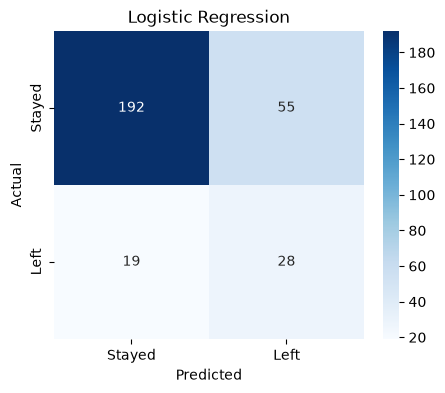

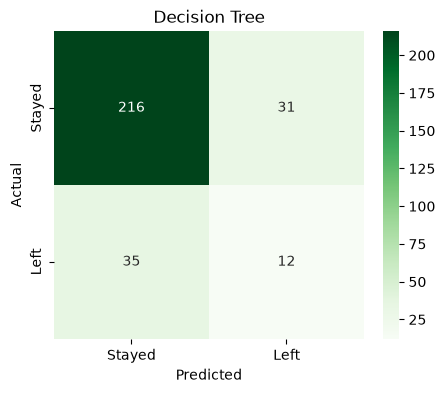

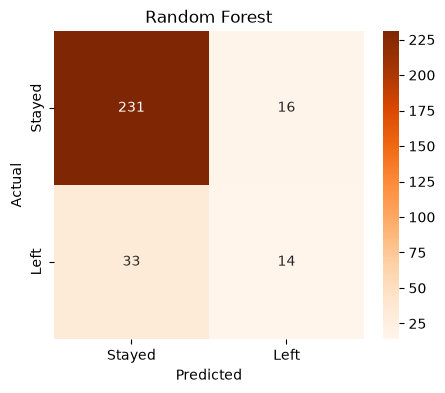

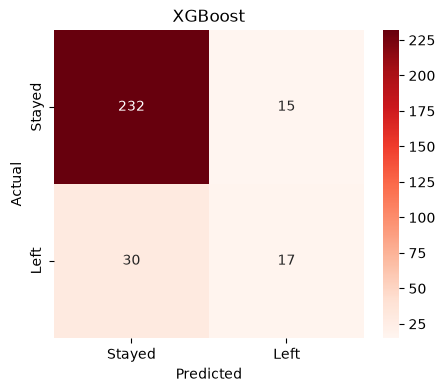

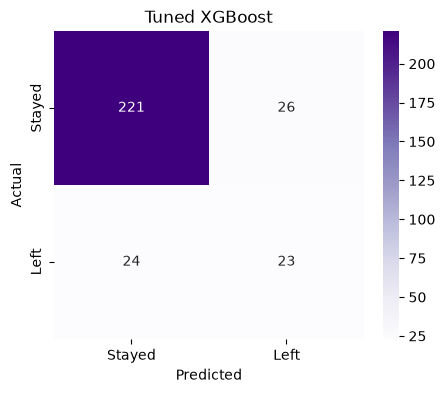

In [118]:
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression", "Blues")
plot_confusion_matrix(y_test, dt_pred, "Decision Tree", "Greens")
plot_confusion_matrix(y_test, rf_pred, "Random Forest", "Oranges")
plot_confusion_matrix(y_test, xgb_pred, "XGBoost", "Reds")
plot_confusion_matrix(y_test, tuned_xgb_pred, "Tuned XGBoost", "Purples")

In [119]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Logistic Regression
print("Logistic Regression")
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print()

# Decision Tree
print("Decision Tree")
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1-score:", f1_score(y_test, dt_pred))
print()

# Random Forest
print("Random Forest")
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))
print()

# XGBoost
print("XGBoost")
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1-score:", f1_score(y_test, xgb_pred))
print()

# Tuned XGBoost
print("Tuned XGBoost")
print("Precision:", precision_score(y_test, tuned_xgb_pred))
print("Recall:", recall_score(y_test, tuned_xgb_pred))
print("F1-score:", f1_score(y_test, tuned_xgb_pred))

Logistic Regression
Precision: 0.3373493975903614
Recall: 0.5957446808510638
F1-score: 0.4307692307692308

Decision Tree
Precision: 0.27906976744186046
Recall: 0.2553191489361702
F1-score: 0.26666666666666666

Random Forest
Precision: 0.4666666666666667
Recall: 0.2978723404255319
F1-score: 0.36363636363636365

XGBoost
Precision: 0.53125
Recall: 0.3617021276595745
F1-score: 0.43037974683544306

Tuned XGBoost
Precision: 0.46938775510204084
Recall: 0.48936170212765956
F1-score: 0.4791666666666667
